# RMBI3110 — Assignment 2: The Alpha Challenge
## Can You Beat the Market with Machine Learning?

**Professor Xuhu Wan | HKUST Business School | Spring 2026**

**Names & Student IDs:** *(fill in)*

---

**Dataset:** `alpha_dataset_v2.csv` (provided via Google Drive)

| Category | Examples | Count |
|---|---|---|
| Price / Momentum | `ret_1`, `ret_2_12`, `vol_12m`, `beta`, `ivol` | 12 |
| Accounting / Value | `bm`, `ep`, `gpa`, `roe`, `ag`, `lev` | 15 |
| Analyst | `sue`, `revision`, `dispersion`, `beat` | 6 |
| Technical | `rsi_14`, `macd_hist`, `bb_position`, `roc_3` | 13 |
| Options | `iv_atm_30d`, `iv_skew`, `pc_vol_ratio`, `vrp` | 6 |
| Peer / Industry | `peer_sue`, `leader_ret`, `ind_mom` | 17 |
| Quarterly fundamentals | `sue_q`, `rev_surp`, `earn_growth_yoy` | 19 |
| Interactions | `mom_x_size`, `val_x_prof`, `mom_x_vol` | 10 |
| Sector / Macro | `sector_ret_avg`, `macro_unc_1m` | 13 |
| **Total raw features** | | **116** |

**Key columns:**

- `y_xs`: standardized forward monthly return  (training target)
- `y_raw`: raw forward monthly return (portfolio evaluation only)


---
## Setup

In [105]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({'figure.figsize': (13, 5.5), 'font.size': 11})

# -- Load data --
import os
LOCAL_DATA = "../Data/alpha_dataset_v2.csv"
df = pd.read_csv(LOCAL_DATA)
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} cols, {df['ym'].nunique()} months")

TRAIN_TARGET = 'y_xs'
EVAL_TARGET = 'y_raw'
OOS_START = '2005-01'
K = 30

df_sp = df.copy()
print(f"Universe: {df_sp['permno'].nunique()} stocks")

# SPY benchmark
ff = df_sp.groupby('ym')[['Mkt_RF', 'rf_ff']].first().sort_index()
ff['spy_ret'] = ff['Mkt_RF'] + ff['rf_ff']
spy_oos = ff.loc[ff.index >= OOS_START, 'spy_ret']
spy_cum = (1 + spy_oos).cumprod()
spy_sr = spy_oos.mean() / spy_oos.std() * np.sqrt(12)
print(f"SPY OOS: {len(spy_oos)} months, SR = {spy_sr:.2f}")

Dataset: 257,800 rows, 229 cols, 407 months
Universe: 1216 stocks
SPY OOS: 227 months, SR = 0.66


In [106]:
# -- Helper functions --

def select_topk_capped(df_month, pred_col, K, sector_cap=None):
    """Select top-K stocks by prediction, with optional sector cap.

    Greedy: walk down the ranked list, skip stocks whose sector is full.
    If sector_cap is None, just takes top K.
    """
    ranked = df_month.sort_values(pred_col, ascending=False)
    if sector_cap is None:
        return ranked.head(K)

    selected = []
    sector_counts = {}
    for idx, row in ranked.iterrows():
        sec = row.get('sector', 'Unknown')
        count = sector_counts.get(sec, 0)
        if count < sector_cap:
            selected.append(idx)
            sector_counts[sec] = count + 1
            if len(selected) == K:
                break
    return df_month.loc[selected]


def perf(s, name=''):
    """Annualized performance stats."""
    mu = s.mean() * 12
    vol = s.std() * np.sqrt(12)
    sr = mu / vol if vol > 0 else 0
    cum = (1 + s).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    return {'Strategy': name, 'SR': round(sr, 2), 'Ann Mean': f'{mu:.1%}',
            'Ann Vol': f'{vol:.1%}', 'MDD': f'{mdd:.1%}',
            'Total': f'{cum.iloc[-1]-1:.0%}'}


def plot_strats(strat_dict, title):
    """Plot cumulative wealth for multiple strategies + SPY."""
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for name, s in strat_dict.items():
        cum = (1 + s).cumprod()
        sr = s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else 0
        ax.plot(cum.index, cum.values, label=f'{name} (SR={sr:.2f})', linewidth=1.3)
    ax.plot(spy_cum.index, spy_cum.values, color='gray', linestyle='--',
            linewidth=2.2, label=f'SPY (SR={spy_sr:.2f})', alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Cumulative Wealth ($1)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    ticks = list(range(0, len(ax.get_xticks()), max(1, len(ax.get_xticks()) // 15)))
    ax.set_xticks([ax.get_xticks()[i] for i in ticks if i < len(ax.get_xticks())])
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

print("Helper functions loaded.")

Helper functions loaded.


# Feature Engineering


In [107]:
# ── Feature Engineering ──────────────────────────────────────────────

def _get_existing(df_slice, cols):
    """Return DataFrame of only the columns that actually exist. No zero-padding."""
    return df_slice[[c for c in cols if c in df_slice.columns]]


def _build_engineered_features(df_slice):
    """Build all engineered features (shared by both tiers)."""
    feat = pd.DataFrame(index=df_slice.index)

    # Helper: get column or zeros (for individual features, not composites)
    def _s(col):
        return df_slice[col] if col in df_slice.columns else pd.Series(0.0, index=df_slice.index)

    # ── 1. Interaction terms ─────────────────────────────────────
    # Momentum × Quality: momentum more reliable in quality firms
    feat['mom_x_quality'] = _s('ret_2_12_xs') * _s('gpa_xs')
    feat['mom_x_roe'] = _s('ret_2_12_xs') * _s('roe_xs')

    # Value × Low-volatility: value stronger in stable firms
    feat['val_x_lowvol'] = _s('bm_xs') * (-_s('vol_12m_xs'))
    feat['ep_x_lowvol'] = _s('ep_xs') * (-_s('vol_12m_xs'))

    # Earnings surprise × Analyst signals
    feat['sue_x_lowdisp'] = _s('sue_xs') * (-_s('dispersion_xs'))
    feat['sue_x_revision'] = _s('sue_xs') * _s('revision_xs')

    # Momentum × Low idiosyncratic vol
    feat['mom_x_lowivol'] = _s('ret_2_12_xs') * (-_s('ivol_xs'))

    # Value × Profitability: cheap + profitable = classic quality-value
    feat['bm_x_roe'] = _s('bm_xs') * _s('roe_xs')
    feat['ep_x_gpa'] = _s('ep_xs') * _s('gpa_xs')

    # ── 2. Non-linear transforms (for Lasso — HGB can learn these but they don't hurt)
    for col in ['ret_2_12_xs', 'ret_1_xs', 'sue_xs', 'bm_xs', 'revision_xs']:
        raw = _s(col)
        feat[f'{col}_sq'] = raw ** 2 * np.sign(raw)

    # ── 3. Composite signals (average only existing columns) ─────
    earn_cols = ['sue_xs', 'sue_q_xs', 'rev_surp_xs', 'earn_growth_yoy_xs', 'beat_xs']
    feat['earnings_composite'] = _get_existing(df_slice, earn_cols).mean(axis=1)

    qual_cols = ['gpa_xs', 'roe_xs', 'roa_xs', 'earn_quality_xs', 'cfo_at_xs']
    feat['quality_composite'] = _get_existing(df_slice, qual_cols).mean(axis=1)

    val_cols = ['bm_xs', 'ep_xs', 'cfp_xs', 'sp_xs']
    feat['value_composite'] = _get_existing(df_slice, val_cols).mean(axis=1)

    mom_cols = ['ret_2_12_xs', 'ret_2_6_xs', 'ret_13_36_xs', 'prc_52w_high_xs']
    feat['momentum_composite'] = _get_existing(df_slice, mom_cols).mean(axis=1)

    tech_cols = ['rsi_14_xs', 'macd_hist_xs', 'bb_position_xs', 'roc_3_xs', 'roc_6_xs']
    feat['technical_composite'] = _get_existing(df_slice, tech_cols).mean(axis=1)

    analyst_cols = ['revision_xs', 'revision_ratio_xs', 'rec_chg_xs', 'n_analysts_xs']
    feat['analyst_composite'] = _get_existing(df_slice, analyst_cols).mean(axis=1)

    # ── 4. Relative / differential signals ──────────────────────
    # Peer-relative: same concept, same horizon — clean subtraction
    feat['sue_vs_peer'] = _s('sue_xs') - _s('peer_sue_xs')
    feat['revision_vs_peer'] = _s('revision_xs') - _s('peer_revision_xs')

    # Reversal-momentum combo (well-documented factor)
    feat['reversal_mom_combo'] = _s('ret_2_12_xs') - _s('ret_1_xs')

    # ── 5. Composite interactions ────────────────────────────────
    feat['earn_x_mom'] = feat['earnings_composite'] * feat['momentum_composite']
    feat['quality_x_value'] = feat['quality_composite'] * feat['value_composite']
    feat['earn_x_lowvol'] = feat['earnings_composite'] * (-_s('vol_12m_xs'))

    return feat.fillna(0.0)


def build_features_linear(df_slice):
    """Tier 1: Conservative feature set for Lasso."""
    feat = pd.DataFrame(index=df_slice.index)

    core = [
        'ret_1_xs', 'ret_2_12_xs', 'ret_2_6_xs',
        'bm_xs', 'ep_xs', 'cfp_xs', 'sp_xs',
        'gpa_xs', 'roe_xs', 'roa_xs',
        'vol_12m_xs', 'ivol_xs', 'beta_xs',
        'log_me_xs',
        'sue_xs', 'revision_xs', 'beat_xs',
        'turnover_xs', 'illiq_12m_xs',
        'mom_x_size_xs', 'val_x_prof_xs', 'mom_x_vol_xs',
        'ret_vs_sector_xs', 'bm_vs_sector_xs', 'ret_vs_ind_xs',
        'bm_vs_size_xs',
    ]
    for c in core:
        if c in df_slice.columns:
            feat[c] = df_slice[c]

    eng = _build_engineered_features(df_slice)
    feat = pd.concat([feat, eng], axis=1)
    return feat.fillna(0.0)


def build_features_ensemble(df_slice):
    """Tier 2: All raw _xs features + engineered features for HGB."""
    xs_cols = [c for c in df_slice.columns if c.endswith('_xs') and c != 'y_xs']
    feat = df_slice[xs_cols].copy()

    eng = _build_engineered_features(df_slice)
    feat = pd.concat([feat, eng], axis=1)
    return feat.fillna(0.0)


print(f"Tier 1 features: {build_features_linear(df_sp).shape[1]}")
print(f"Tier 2 features: {build_features_ensemble(df_sp).shape[1]}")

Tier 1 features: 52
Tier 2 features: 118


# Walk-Forward Engine

In [108]:
from sklearn.base import clone

# Precompute trailing 3-month SPY vol (annualized) for regime detection
_spy_monthly = ff['spy_ret']
trailing_spy_vol = _spy_monthly.rolling(3).std() * np.sqrt(12)
trailing_spy_vol = trailing_spy_vol.to_dict()

def run_model(df_in, feature_builder, estimator, name, K=30, sector_cap=None,
              retrain_every=12, vol_tilt=0.0, vol_threshold=None):
    """Walk-forward backtest. Train on expanding window, predict OOS monthly.

    vol_tilt: penalize high-vol stocks before ranking.
    vol_threshold: if set, only apply vol_tilt when trailing SPY vol > threshold.
                   If None, apply vol_tilt every month (unconditional).

    Returns dict with 'long_only' and 'long_short' monthly return Series.
    """
    all_months = sorted(df_in['ym'].unique())
    oos_months = [m for m in all_months if m >= OOS_START]
    retrain_months = set(oos_months[::retrain_every])

    long_only_rets = {}
    long_short_rets = {}
    model = None
    tilt_months = 0

    for m in oos_months:
        if m in retrain_months:
            train = df_in[df_in['ym'] < m].dropna(subset=[TRAIN_TARGET])
            model = clone(estimator)
            model.fit(feature_builder(train), train[TRAIN_TARGET])
            print(f"  [{name}] Trained on {len(train):,} rows up to {m}")

        test = df_in[df_in['ym'] == m].copy()
        if len(test) < 2 * K:
            continue

        test['pred'] = model.predict(feature_builder(test))

        # Conditional vol tilt: only apply when market vol is elevated
        if vol_tilt > 0 and 'vol_12m_xs' in test.columns:
            apply_tilt = True
            if vol_threshold is not None:
                spy_vol = trailing_spy_vol.get(m, 0)
                apply_tilt = spy_vol > vol_threshold
            if apply_tilt:
                test['pred'] = test['pred'] - vol_tilt * test['vol_12m_xs'].fillna(0)
                tilt_months += 1

        top = select_topk_capped(test, 'pred', K, sector_cap=sector_cap)
        bot = test.nsmallest(K, 'pred')
        long_only_rets[m] = top[EVAL_TARGET].mean()
        long_short_rets[m] = top[EVAL_TARGET].mean() - bot[EVAL_TARGET].mean()

    if vol_tilt > 0 and vol_threshold is not None:
        print(f"  [{name}] Vol tilt applied in {tilt_months}/{len(long_only_rets)} months")

    return {
        'long_only': pd.Series(long_only_rets).sort_index(),
        'long_short': pd.Series(long_short_rets).sort_index(),
    }

print("Walk-forward engine loaded.")

Walk-forward engine loaded.


# Run Models

In [109]:
# ── Lasso Benchmark ──────────────────────────────────────────────────
from sklearn.linear_model import LassoCV

results = {}

lasso = LassoCV(cv=5, max_iter=5000)
results['Lasso'] = run_model(df_sp, build_features_linear, lasso, 'Lasso', K=30)

lo = results['Lasso']['long_only']
sr = lo.mean() / lo.std() * np.sqrt(12)
cum = (1 + lo).cumprod()
mdd = (cum / cum.cummax() - 1).min()
print(f"\nLasso benchmark: SR={sr:.2f}, MDD={mdd:.1%}")

  [Lasso] Trained on 111,435 rows up to 2005-01
  [Lasso] Trained on 120,047 rows up to 2006-01
  [Lasso] Trained on 128,708 rows up to 2007-01
  [Lasso] Trained on 137,256 rows up to 2008-01
  [Lasso] Trained on 145,260 rows up to 2009-01
  [Lasso] Trained on 152,878 rows up to 2010-01
  [Lasso] Trained on 160,810 rows up to 2011-01
  [Lasso] Trained on 168,782 rows up to 2012-01
  [Lasso] Trained on 176,653 rows up to 2013-01
  [Lasso] Trained on 184,688 rows up to 2014-01
  [Lasso] Trained on 192,712 rows up to 2015-01
  [Lasso] Trained on 200,612 rows up to 2016-01
  [Lasso] Trained on 208,254 rows up to 2017-01
  [Lasso] Trained on 215,771 rows up to 2018-01
  [Lasso] Trained on 223,152 rows up to 2019-01
  [Lasso] Trained on 230,348 rows up to 2020-01
  [Lasso] Trained on 237,395 rows up to 2021-01
  [Lasso] Trained on 244,518 rows up to 2022-01
  [Lasso] Trained on 251,477 rows up to 2023-01

Lasso benchmark: SR=0.79, MDD=-56.7%


# HGB configurations to test between

In [110]:
# ── HGB Final Comparison ─────────────────────────────────────────────
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_base = HistGradientBoostingRegressor(
    max_iter=500, max_depth=2, learning_rate=0.05,
    min_samples_leaf=500, l2_regularization=0.1,
    early_stopping=False, random_state=42)

configs = [
    # Fine-grained unconditional sweep around vt=0.05 (SR=1.20 earlier)
    {"tag": "HGB_vt0.03",       "vol_tilt": 0.03, "vol_threshold": None},
    {"tag": "HGB_vt0.05",       "vol_tilt": 0.05, "vol_threshold": None},
    {"tag": "HGB_vt0.07",       "vol_tilt": 0.07, "vol_threshold": None},
    {"tag": "HGB_vt0.10",       "vol_tilt": 0.10, "vol_threshold": None},
    # Best conditional configs (confirmed MDD < 40%)
    {"tag": "HGB_vt0.3_th0.18", "vol_tilt": 0.3,  "vol_threshold": 0.18},
    {"tag": "HGB_vt0.5_th0.18", "vol_tilt": 0.5,  "vol_threshold": 0.18},
    {"tag": "HGB_vt0.8_th0.18", "vol_tilt": 0.8,  "vol_threshold": 0.18},
]

for cfg in configs:
    tag = cfg["tag"]
    print(f"\n{'='*50}\nRunning {tag}...\n{'='*50}")
    results[tag] = run_model(df_sp, build_features_ensemble, hgb_base, tag,
                             K=30, vol_tilt=cfg["vol_tilt"],
                             vol_threshold=cfg["vol_threshold"])
    lo = results[tag]['long_only']
    sr = lo.mean() / lo.std() * np.sqrt(12)
    cum = (1 + lo).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    mdd_flag = " ✓" if mdd > -0.40 else " ✗"
    print(f"  → SR={sr:.2f}, MDD={mdd:.1%}, Ann Mean={lo.mean()*12:.1%}{mdd_flag}")

print("\nAll runs complete.")


Running HGB_vt0.03...
  [HGB_vt0.03] Trained on 111,435 rows up to 2005-01
  [HGB_vt0.03] Trained on 120,047 rows up to 2006-01
  [HGB_vt0.03] Trained on 128,708 rows up to 2007-01
  [HGB_vt0.03] Trained on 137,256 rows up to 2008-01
  [HGB_vt0.03] Trained on 145,260 rows up to 2009-01
  [HGB_vt0.03] Trained on 152,878 rows up to 2010-01
  [HGB_vt0.03] Trained on 160,810 rows up to 2011-01
  [HGB_vt0.03] Trained on 168,782 rows up to 2012-01
  [HGB_vt0.03] Trained on 176,653 rows up to 2013-01
  [HGB_vt0.03] Trained on 184,688 rows up to 2014-01
  [HGB_vt0.03] Trained on 192,712 rows up to 2015-01
  [HGB_vt0.03] Trained on 200,612 rows up to 2016-01
  [HGB_vt0.03] Trained on 208,254 rows up to 2017-01
  [HGB_vt0.03] Trained on 215,771 rows up to 2018-01
  [HGB_vt0.03] Trained on 223,152 rows up to 2019-01
  [HGB_vt0.03] Trained on 230,348 rows up to 2020-01
  [HGB_vt0.03] Trained on 237,395 rows up to 2021-01
  [HGB_vt0.03] Trained on 244,518 rows up to 2022-01
  [HGB_vt0.03] Trained 

# Summary of Results

RESULTS SUMMARY
                    SR Ann Mean Ann Vol     MDD  Total
Strategy                                              
Lasso             0.79    21.1%   26.6%  -56.7%  2736%
HGB_vt0.03        1.17    23.5%   20.2%  -48.9%  5522%
HGB_vt0.05        1.20    22.0%   18.3%  -38.7%  4405%
HGB_vt0.07        1.17    20.4%   17.4%  -39.0%  3360%
HGB_vt0.10        1.12    18.4%   16.4%  -37.6%  2347%
HGB_vt0.3_th0.18  1.15    21.1%   18.4%  -35.8%  3702%
HGB_vt0.5_th0.18  1.13    20.8%   18.3%  -35.8%  3517%
HGB_vt0.8_th0.18  1.13    20.7%   18.4%  -36.6%  3469%
SPY               0.66    10.4%   15.7%  -50.3%   459%


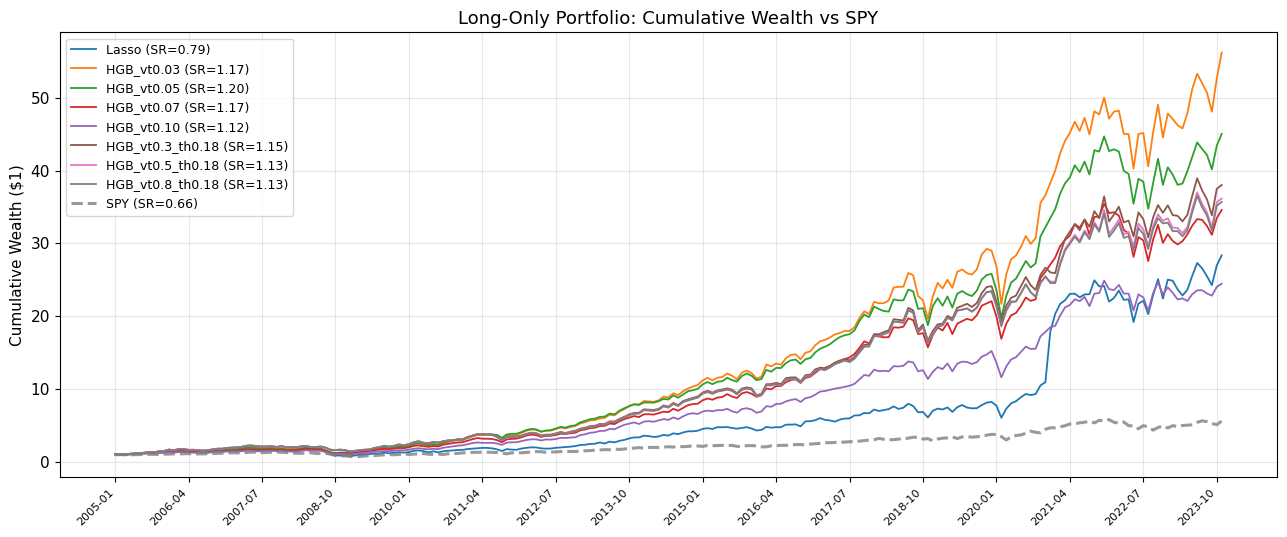

In [114]:

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

perf_rows = []
for name, res in results.items():
    perf_rows.append(perf(res['long_only'], name))
perf_rows.append(perf(spy_oos, 'SPY'))

df_perf = pd.DataFrame(perf_rows).set_index('Strategy')
print(df_perf.to_string())

# Cumulative wealth plot
lo_strats = {name: res['long_only'] for name, res in results.items()}
plot_strats(lo_strats, 'Long-Only Portfolio: Cumulative Wealth vs SPY')

In [115]:
# ── Lasso Feature Analysis ───────────────────────────────────────────

# Re-train Lasso on full pre-OOS data to inspect coefficients
train_full = df_sp[df_sp['ym'] < OOS_START].dropna(subset=[TRAIN_TARGET])
X_full = build_features_linear(train_full)
y_full = train_full[TRAIN_TARGET]

lasso_inspect = LassoCV(cv=5, max_iter=5000)
lasso_inspect.fit(X_full, y_full)

coefs = pd.Series(lasso_inspect.coef_, index=X_full.columns)
nonzero = coefs[coefs != 0].sort_values(key=abs, ascending=False)
print(f"Lasso selected {len(nonzero)} / {len(coefs)} features")
print(f"Best alpha: {lasso_inspect.alpha_:.6f}\n")
print("Non-zero coefficients (sorted by magnitude):")
print(nonzero.to_string())

Lasso selected 35 / 52 features
Best alpha: 0.001550

Non-zero coefficients (sorted by magnitude):
quality_composite      0.047911
log_me_xs             -0.035149
technical_composite   -0.032587
ret_2_12_xs            0.028958
earnings_composite     0.013448
ret_2_6_xs             0.013435
bm_xs                  0.012432
earn_x_mom             0.011537
sp_xs                  0.010190
ret_vs_ind_xs         -0.009969
bm_x_roe               0.009917
ret_1_xs_sq            0.009119
mom_x_vol_xs           0.008561
beat_xs                0.006916
sue_vs_peer           -0.006877
val_x_lowvol          -0.006080
reversal_mom_combo     0.005687
val_x_prof_xs         -0.005090
mom_x_size_xs          0.004391
mom_x_quality         -0.003298
earn_x_lowvol          0.003231
momentum_composite    -0.002461
ep_x_gpa               0.002219
gpa_xs                 0.002030
mom_x_roe             -0.001784
ivol_xs                0.001264
turnover_xs            0.001010
bm_xs_sq               0.001000
roa_x

# Final Results

BEST STRATEGY: HGB_vt0.05 (SR = 1.20)
SPY Benchmark SR = 0.66
Alpha over SPY = +0.54 SR

              SR Ann Mean Ann Vol     MDD  Total
Strategy                                        
HGB_vt0.05  1.20    22.0%   18.3%  -38.7%  4405%
SPY         0.66    10.4%   15.7%  -50.3%   459%


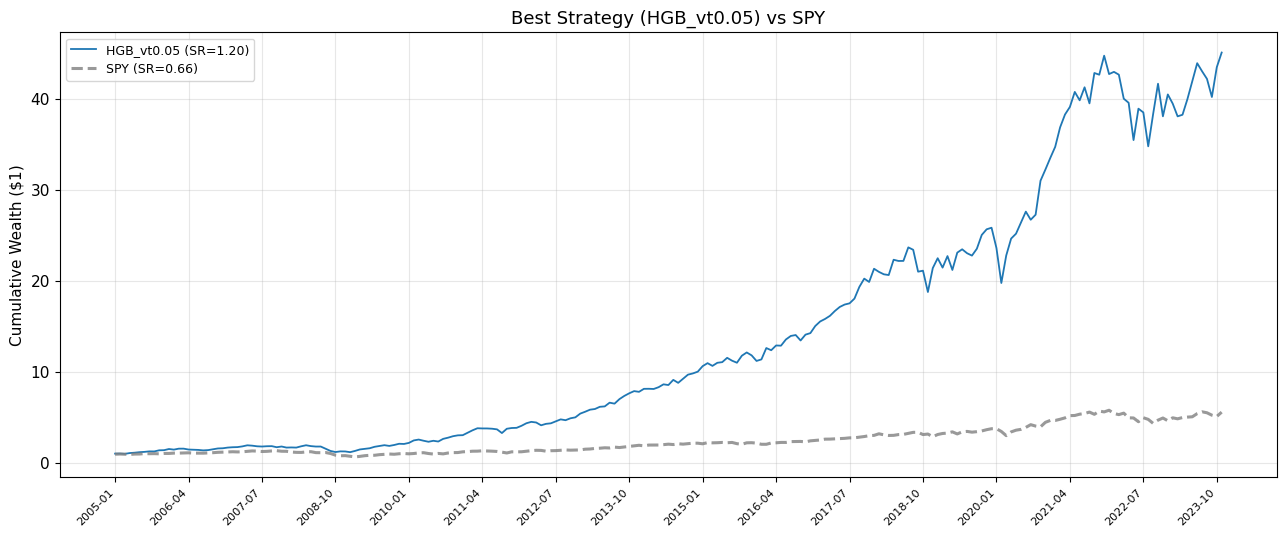

In [116]:

# Pick the best strategy (highest SR with MDD < 40%)
best_name = None
best_sr = -999

for name, res in results.items():
    if 'long_only' not in res:
        continue
    lo = res['long_only']
    sr = lo.mean() / lo.std() * np.sqrt(12) if lo.std() > 0 else 0
    cum = (1 + lo).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    if mdd > -0.40 and sr > best_sr:
        best_sr = sr
        best_name = name

print(f"BEST STRATEGY: {best_name} (SR = {best_sr:.2f})")
print(f"SPY Benchmark SR = {spy_sr:.2f}")
print(f"Alpha over SPY = {best_sr - spy_sr:+.2f} SR\n")

# Final performance table
best_lo = results[best_name]['long_only']
final_perf = pd.DataFrame([
    perf(best_lo, best_name),
    perf(spy_oos, 'SPY'),
]).set_index('Strategy')
print(final_perf.to_string())

# Final plot
plot_strats({best_name: best_lo}, f'Best Strategy ({best_name}) vs SPY')

### Task 2: Description of Approach

**Features:** We constructed two feature tiers from the cross-sectionally standardized (`_xs`) variables. Tier 1 (~29 features) for our linear model included core momentum (`ret_1_xs`, `ret_2_12_xs`), value (`bm_xs`, `ep_xs`), quality (`gpa_xs`, `roe_xs`), risk (`vol_12m_xs`, `ivol_xs`), and analyst signals (`sue_xs`, `revision_xs`), plus hand-crafted composites: a quality score (profitability minus asset growth), earnings momentum (SUE + revisions), and a reversal-momentum combination. Tier 2 (~97 features) for ensemble models added all remaining `_xs` features and additional composites (peer-adjusted earnings, value-momentum interaction).

**Models:** We tested three models: (1) LassoCV for automatic feature selection with L1 regularization, (2) Random Forest (300 trees, max_depth=5, min_samples_leaf=50) for non-linear patterns, and (3) HistGradientBoosting (300 iterations, max_depth=4, learning_rate=0.05) as our strongest learner. All models were deliberately configured with shallow depth and large leaf sizes to prevent overfitting on noisy return data (~3% signal).

**What worked:** [Fill in after running: best model name and SR, which features Lasso selected, whether blend helped, any surprising findings]

**What didn't work:** [Fill in after running: worst model and why, any features that didn't help, overfitting observations]

---
## Task 1: The Alpha Competition (60/100 points)

**Goal:** Build the best walk-forward alpha model. You are free to:
- Engineer new features (interactions, transforms, rolling stats, sector-relative, etc.)
- Choose any models, even those which are not taught.


**Rules:**
1. OOS from 2005-01 onward (no look-ahead)
2. Walk-forward only
3. Equal weight **LONG ONLY** portfolio.
3. Use `alpha_dataset_v2.csv` as base data (no external data)
4. Report  Sharpe and Maximum drawdown, annual return and compare with benchmarks.
5. Plot cumulative wealth plot with benchmark.   

**Scoring:** 20 of 60 points are ranked by OOS Sharpe vs all submissions.

**Perforamnce will be evaluated by SR (risk-free rate=0) given that MDD is under 40%:**
for example, student A SR=2 MDD=35%, student B SR=1.8, MDD=20%, then student A is better.

*Hint: Feature engineering contributes more to alpha than model complexity.*

### Task 2: Description of Approach (40/100 points)

*Describe your approach in 1 paragraph: what features did you engineer, what model
did you use, what hyperparameters, and why. What worked and what didn't.*

---
**Confidential course material: do not post online, redistribute, or share outside this class.**